# kmin Regression with ResNet50 (PyTorch)

**Goal**: Predict kmin from fractal cube images using regression.

**Memory optimized**: Lazy HDF5 loading, grayscale→RGB conversion on-the-fly.

In [1]:
from pathlib import Path
import json
import time

import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [2]:
candidate_files = [
    Path('../../data/raw/flexible_20260425_221800_128x128_100000.h5'),
]

DATA_FILE = next((p for p in candidate_files if p.exists()), None)
OUTPUT_DIR = Path('../../outputs/kmin/regression')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 16
LEARNING_RATE = 1e-4
EPOCHS = 50
EARLY_STOP_PATIENCE = 7

KMIN_MIN, KMIN_MAX = 1.0, 32.0

if DATA_FILE is None:
    raise FileNotFoundError('Dataset not found')
print(f'Dataset: {DATA_FILE}')

Dataset: ../../data/raw/flexible_20260425_221800_128x128_100000.h5


## Memory-Efficient Dataset (Lazy Loading)

In [3]:
class HDF5Dataset(Dataset):
    """Lazy-loading HDF5 dataset - loads images on demand."""
    
    def __init__(self, h5_path, indices, kmin_values, kmin_min=1.0, kmin_max=32.0):
        self.h5_path = h5_path
        self.indices = indices
        self.kmin = kmin_values[indices]
        self.kmin_min = kmin_min
        self.kmin_max = kmin_max
        self._h5_file = None
    
    def _get_h5(self):
        if self._h5_file is None:
            self._h5_file = h5py.File(self.h5_path, 'r')
        return self._h5_file
    
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        h5 = self._get_h5()
        img_idx = self.indices[idx]
        
        # Load single image (grayscale)
        img = h5['images'][img_idx].astype(np.float32)
        
        # Normalize to [0, 1]
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        
        # Keep as 1 channel (1, H, W)
        img = img[np.newaxis, :, :]
        
        # Normalize target to [0, 1]
        y = (self.kmin[idx] - self.kmin_min) / (self.kmin_max - self.kmin_min)
        
        return torch.from_numpy(img), torch.tensor(y, dtype=torch.float32)
    
    def __del__(self):
        if self._h5_file is not None:
            self._h5_file.close()

In [4]:
# Only load metadata, not images
with h5py.File(DATA_FILE, 'r') as f:
    n_samples = f['images'].shape[0]
    kmin_values = f['parameters/k_min'][:]

print(f'Total samples: {n_samples}')
print(f'kmin range: [{kmin_values.min():.1f}, {kmin_values.max():.1f}]')
print(f'RAM usage: ~{kmin_values.nbytes / 1e6:.1f} MB (metadata only)')

Total samples: 100000
kmin range: [1.0, 32.0]
RAM usage: ~0.4 MB (metadata only)


In [5]:
# Split indices, not data
indices = np.arange(n_samples)
train_idx, temp_idx = train_test_split(indices, test_size=0.2, random_state=SEED)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=SEED)

# Create datasets with lazy loading
train_ds = HDF5Dataset(DATA_FILE, train_idx, kmin_values, KMIN_MIN, KMIN_MAX)
val_ds = HDF5Dataset(DATA_FILE, val_idx, kmin_values, KMIN_MIN, KMIN_MAX)
test_ds = HDF5Dataset(DATA_FILE, test_idx, kmin_values, KMIN_MIN, KMIN_MAX)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}')

Train: 80000, Val: 10000, Test: 10000


## Model

In [6]:
class ResNet50Regressor(nn.Module):
    def __init__(self, in_channels=1, pretrained=False):
        super().__init__()
        weights = models.ResNet50_Weights.DEFAULT if pretrained else None
        self.backbone = models.resnet50(weights=weights)
        
        # Modify first conv to accept 1 channel instead of 3
        self.backbone.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        return self.backbone(x).squeeze(-1)

model = ResNet50Regressor(in_channels=1, pretrained=False).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 24,042,817


In [10]:
LOSS_TYPE = 'rmse'  # Options: 'rmse', 'rmse_mae'
RMSE_MAE_ALPHA = 0.7      # Used only when LOSS_TYPE='rmse_mae'
RMSE_EPS = 1e-8

class RegressionLoss(nn.Module):
    def __init__(self, loss_type='rmse_mae', alpha=0.7, eps=1e-8):
        super().__init__()
        self.loss_type = loss_type
        self.alpha = alpha
        self.eps = eps

    def forward(self, pred, target):
        mse = torch.mean((pred - target) ** 2)
        rmse = torch.sqrt(mse + self.eps)

        if self.loss_type == 'rmse':
            return rmse

        if self.loss_type == 'rmse_mae':
            mae = torch.mean(torch.abs(pred - target))
            return self.alpha * rmse + (1.0 - self.alpha) * mae

        raise ValueError(f'Unsupported loss_type: {self.loss_type}')

criterion = RegressionLoss(loss_type=LOSS_TYPE, alpha=RMSE_MAE_ALPHA, eps=RMSE_EPS)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-7)
scaler = torch.amp.GradScaler('cuda') if DEVICE.type == 'cuda' else None

## Train

In [11]:
def train_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()

        if scaler:
            with torch.amp.autocast('cuda'):
                pred = model(X_batch)
                loss = criterion(pred, y_batch)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * len(X_batch)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    preds, targets = [], []
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        total_loss += loss.item() * len(X_batch)
        preds.append(pred.cpu())
        targets.append(y_batch.cpu())

    preds = torch.cat(preds).numpy()
    targets = torch.cat(targets).numpy()
    rmse = np.sqrt(np.mean((preds - targets) ** 2))
    mae = np.mean(np.abs(preds - targets))

    return total_loss / len(loader.dataset), rmse, mae, preds, targets

In [12]:
history = {'train_loss': [], 'val_loss': [], 'val_rmse': [], 'val_mae': []}
best_val_rmse = float('inf')
patience_counter = 0

start_time = time.time()

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, scaler)
    val_loss, val_rmse, val_mae, _, _ = eval_epoch(model, val_loader, criterion)
    scheduler.step(val_rmse)

    history['train_loss'].append(float(train_loss))
    history['val_loss'].append(float(val_loss))
    history['val_rmse'].append(float(val_rmse))
    history['val_mae'].append(float(val_mae))

    lr = optimizer.param_groups[0]['lr']
    print(
        f'Epoch {epoch+1:3d} | Train: {train_loss:.4f} | '
        f'ValLoss: {val_loss:.4f} | RMSE: {val_rmse:.4f} | MAE: {val_mae:.4f} | LR: {lr:.2e}'
    )

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        patience_counter = 0
        torch.save(model.state_dict(), OUTPUT_DIR / 'best_model.pt')
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

train_time = time.time() - start_time
print(f'\nTraining: {train_time/60:.1f} min')

Epoch   1 | Train: 0.0535 | ValLoss: 0.0972 | RMSE: 0.0989 | MAE: 0.0721 | LR: 1.00e-04
Epoch   2 | Train: 0.0480 | ValLoss: 0.0699 | RMSE: 0.0711 | MAE: 0.0541 | LR: 1.00e-04
Epoch   3 | Train: 0.0449 | ValLoss: 0.0720 | RMSE: 0.0733 | MAE: 0.0547 | LR: 1.00e-04
Epoch   4 | Train: 0.0423 | ValLoss: 0.0769 | RMSE: 0.0788 | MAE: 0.0539 | LR: 1.00e-04
Epoch   5 | Train: 0.0436 | ValLoss: 1.0695 | RMSE: 1.6212 | MAE: 0.3474 | LR: 1.00e-04
Epoch   6 | Train: 0.0441 | ValLoss: 0.1639 | RMSE: 0.3088 | MAE: 0.0762 | LR: 1.00e-04
Epoch   7 | Train: 0.0410 | ValLoss: 1.6569 | RMSE: 2.8213 | MAE: 0.5041 | LR: 1.00e-04
Epoch   8 | Train: 0.0406 | ValLoss: 1.4912 | RMSE: 1.9841 | MAE: 0.5137 | LR: 5.00e-05
Epoch   9 | Train: 0.0381 | ValLoss: 0.3581 | RMSE: 0.5641 | MAE: 0.1347 | LR: 5.00e-05
Early stopping at epoch 9

Training: 40.9 min


## Evaluate

In [13]:
model.load_state_dict(torch.load(OUTPUT_DIR / 'best_model.pt'))
_, _, _, y_pred_norm, y_true_norm = eval_epoch(model, test_loader, criterion)

# Denormalize
y_pred = y_pred_norm * (KMIN_MAX - KMIN_MIN) + KMIN_MIN
y_true = y_true_norm * (KMIN_MAX - KMIN_MIN) + KMIN_MIN

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print('=== Test Metrics ===')
print(f'MAE:  {mae:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'R²:   {r2:.4f}')

=== Test Metrics ===
MAE:  1.632
RMSE: 2.152
R²:   0.9418


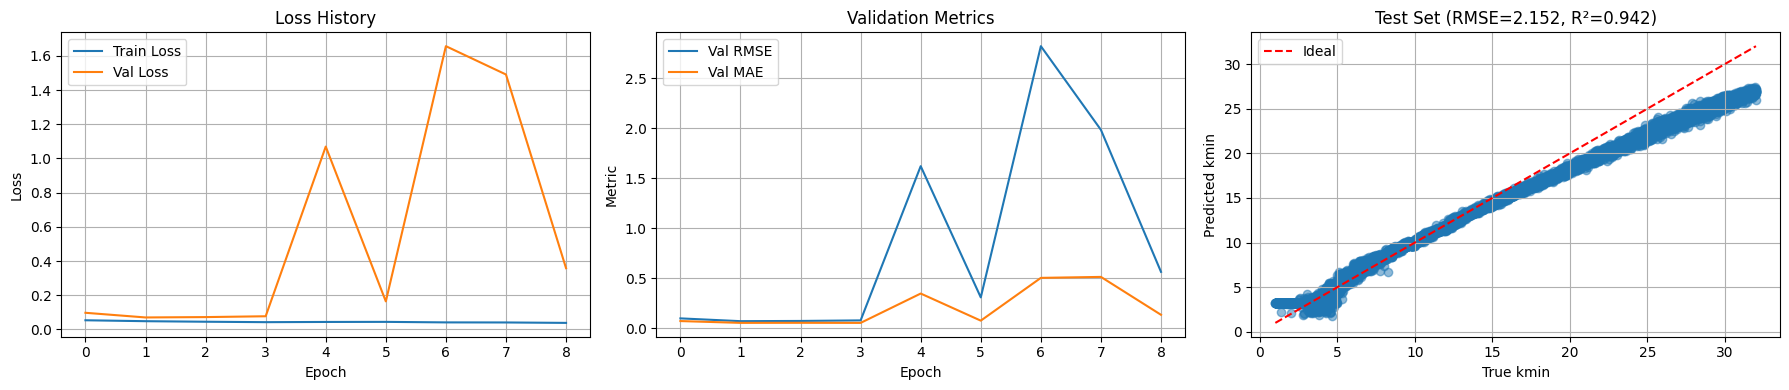

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss History')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['val_rmse'], label='Val RMSE')
axes[1].plot(history['val_mae'], label='Val MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Metric')
axes[1].set_title('Validation Metrics')
axes[1].legend()
axes[1].grid(True)

axes[2].scatter(y_true, y_pred, alpha=0.5)
axes[2].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Ideal')
axes[2].set_xlabel('True kmin')
axes[2].set_ylabel('Predicted kmin')
axes[2].set_title(f'Test Set (RMSE={rmse:.3f}, R²={r2:.3f})')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [13]:
results = {
    'mae': float(mae),
    'rmse': float(rmse),
    'r2': float(r2),
    'param_range': [float(KMIN_MIN), float(KMIN_MAX)],
    'training_time_min': train_time / 60
}

with open(OUTPUT_DIR / 'test_results.json', 'w') as f:
    json.dump(results, f, indent=2)

with open(OUTPUT_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f)

print('Results saved to', OUTPUT_DIR)

TypeError: Object of type float32 is not JSON serializable